In [6]:
# imports
import json
from src.config import PATH_FIG
from src.analysis.moralchoice_analysis import calculate_moralchoice_results
from src.analysis.utils import plot_single_bar_chart

OUTPUT_DIR = PATH_FIG / "moralchoice"

In [7]:
result_configs = [
    # high ambiguity
    (
        "main/moralchoice_high_ambiguity/google_gemma-3-4b-it_moralchoice_high_ambiguity.csv",
        "moralchoice_high_ambiguity.csv",
        "gemma-3-4b-it high ambiguity"
    ),
    (
        "main/moralchoice_high_ambiguity/meta-llama_Llama-3.2-3B-Instruct_moralchoice_high_ambiguity.csv",
        "moralchoice_high_ambiguity.csv",
        "Llama-3.2-3B-Instruct high ambiguity"
    ),
    (
        "main/moralchoice_high_ambiguity/Qwen_Qwen3-4B_moralchoice_high_ambiguity.csv",
        "moralchoice_high_ambiguity.csv",
        "Qwen3-4B high ambiguity"
    ),
    (
        "main/moralchoice_high_ambiguity/openai_gpt-4.1_moralchoice_high_ambiguity.csv",
        "moralchoice_high_ambiguity.csv",
        "GPT-4.1 high ambiguity"
    ),
    # low ambiguity
    (
        "main/moralchoice_low_ambiguity/google_gemma-3-4b-it_moralchoice_low_ambiguity.csv",
        "moralchoice_low_ambiguity.csv",
        "gemma-3-4b-it low ambiguity"
    ),
    (
        "main/moralchoice_low_ambiguity/meta-llama_Llama-3.2-3B-Instruct_moralchoice_low_ambiguity.csv",
        "moralchoice_low_ambiguity.csv",
        "Llama-3.2-3B-Instruct low ambiguity"
    ),
    (
        "main/moralchoice_low_ambiguity/Qwen_Qwen3-4B_moralchoice_low_ambiguity.csv",
        "moralchoice_low_ambiguity.csv",
        "Qwen3-4B low ambiguity"
    ),
    (
        "main/moralchoice_low_ambiguity/Qwen_Qwen3-4b_moralchoice_low_ambiguity_short.csv",
        "moralchoice_low_ambiguity.csv",
        "Qwen3-4B low ambiguity short"
    ),  # subset of 50 scenarios for comparison with reasoning ablation
    (
        "main/moralchoice_low_ambiguity/openai_gpt-4.1_moralchoice_low_ambiguity.csv",
        "moralchoice_low_ambiguity.csv",
        "GPT-4.1 low ambiguity"
    ),
    # multimodal
    (
        "multimodal/google_gemma-3-4b-it_multimodality_high_ambiguity.csv",
        "moralchoice_high_ambiguity.csv",
        "gemma-3-4b-it multimodal high ambiguity"
    ),
    (
        "multimodal/google_gemma-3-4b-it_multimodality_low_ambiguity.csv",
        "moralchoice_low_ambiguity.csv",
        "gemma-3-4b-it multimodal low ambiguity"
    ),
    (
        "multimodal/Qwen_Qwen3-VL-4B-Instruct_moralchoice_high_ambiguity.csv",
        "moralchoice_high_ambiguity.csv",
        "Qwen3-VL-4B-Instruct multimodal high ambiguity"
    ),
    (
        "multimodal/Qwen_Qwen3-VL-4B-Instruct_moralchoice_low_ambiguity.csv",
        "moralchoice_low_ambiguity.csv",
        "Qwen3-VL-4B-Instruct multimodal low ambiguity"
    ),
    # instruction-tuning
    (
        "ablation/base/google_gemma-3-4b-pt_low_ambiguity.csv",
        "moralchoice_low_ambiguity.csv",
        "gemma-3-4b-pt low ambiguity"
    ),
    (
        "ablation/base/meta-llama_Llama-3.2-3B_low_ambiguity.csv",
        "moralchoice_low_ambiguity.csv",
        "Llama-3.2-3B low ambiguity"
    ),
    (
        "ablation/base/Qwen_Qwen3-4B-Base_low_ambiguity.csv",
        "moralchoice_low_ambiguity.csv",
        "Qwen3-4B-Base low ambiguity"
    ),
    # prompt engineering
    (
        "ablation/prompt engineering/google_gemma-3-4b-it_moralchoice_low_ambiguity.csv",
        "moralchoice_low_ambiguity.csv",
        "gemma-3-4b-it prompt engineering low ambiguity"
    ),
    (
        "ablation/prompt engineering/meta-llama_Llama-3.2-3B-Instruct_moralchoice_low_ambiguity.csv",
        "moralchoice_low_ambiguity.csv",
        "Llama-3.2-3B-Instruct prompt engineering low ambiguity"
    ),
    (
        "ablation/prompt engineering/Qwen_Qwen3-4B_moralchoice_low_ambiguity.csv",
        "moralchoice_low_ambiguity.csv",
        "Qwen3-4B prompt engineering low ambiguity"
    ),
    (
        "ablation/prompt engineering/openai_gpt-4.1_moralchoice_low_ambiguity.csv",
        "moralchoice_low_ambiguity.csv",
        "GPT-4.1 prompt engineering low ambiguity"
    ),
    # size
    (
        "ablation/size/google_gemma-3-1b-it_moralchoice_low_ambiguity.csv",
        "moralchoice_low_ambiguity.csv",
        "gemma-3-1b-it low ambiguity"
    ),
    (
        "ablation/size/google_gemma-3-270m-it_moralchoice_low_ambiguity.csv",
        "moralchoice_low_ambiguity.csv",
        "gemma-3-270m-it low ambiguity"
    ),
    (
        "ablation/size/meta-llama_Llama-3.2-1B-Instruct_low_ambiguity.csv",
        "moralchoice_low_ambiguity.csv",
        "Llama-3.2-1B-Instruct low ambiguity"
    ),
    (
        "ablation/size/Qwen_Qwen3-1.7B_low_ambiguity.csv",
        "moralchoice_low_ambiguity.csv",
        "Qwen3-1.7B low ambiguity"
    ),
    (
        "ablation/size/Qwen_Qwen3-0.6B_low_ambiguity.csv",
        "moralchoice_low_ambiguity.csv",
        "Qwen3-0.6B low ambiguity"
    ),
    # reasoning
    (
        "ablation/thinking/Qwen_Qwen3-4B_thinking_high_ambiguity.csv",
        "moralchoice_high_ambiguity.csv",
        "Qwen3-4B thinking high ambiguity"
    ),
    (
        "ablation/thinking/Qwen_Qwen3-4B_thinking_low_ambiguity.csv",
        "moralchoice_low_ambiguity.csv",
        "Qwen3-4B thinking low ambiguity"
    )
]

In [8]:
def run_moralchoice_analysis():
    all_results = {}

    for config in result_configs:
        csv_results_filepath, scenario_filepath, figure_name = config
        results = calculate_moralchoice_results(csv_results_filepath, scenario_filepath)
        all_results[figure_name] = {
            'mean_scores': dict((option, option_results['mean_scores']) for option, option_results in results.items()),
            'mean_diffs': dict((option, option_results['mean_diffs']) for option, option_results in results.items()),
            'st_error_scores': dict((option, option_results['st_error_scores']) for option, option_results in results.items()),
            'st_error_diffs': dict((option, option_results['st_error_diffs']) for option, option_results in results.items()),
            'sig': dict((option, option_results['sig']) for option, option_results in results.items())
        }

        print(figure_name)
        for analysis, results in all_results[figure_name].items():
            print(f"{analysis}: {json.dumps(results, indent=4)}\n")

    return all_results

all_moralchoice_results = run_moralchoice_analysis()

gemma-3-4b-it high ambiguity
mean_scores: {
    "all": {
        "baseline": 0.6382800039555618,
        "positive": 0.6589659445560377,
        "neutral": 0.6529429080751802,
        "negative": 0.6286993957229956
    }
}

mean_diffs: {
    "all": {
        "baseline": 0.0,
        "positive": 0.020685940600475745,
        "neutral": 0.014662904119618172,
        "negative": -0.009580608232566418
    }
}

st_error_scores: {
    "all": {
        "baseline": 0.007168993361193858,
        "positive": 0.0022291961916712528,
        "neutral": 0.002239871097784329,
        "negative": 0.00225430148013788
    }
}

st_error_diffs: {
    "all": {
        "baseline": 0.0,
        "positive": 0.0017382387469354697,
        "neutral": 0.0017255927008342788,
        "negative": 0.0017983414875818325
    }
}

sig: {
    "all": {}
}

Llama-3.2-3B-Instruct high ambiguity
mean_scores: {
    "all": {
        "baseline": 0.5609222831143226,
        "positive": 0.5225178670148506,
        "neutral": 0.5

In [9]:
def plot_moralchoice_bar_chart(
        result_keys,
        x_labels,
        output_filename,
        figsize,
        xlabel="Model",
        absolute=False
):
    plot_single_bar_chart(
        results=all_moralchoice_results,
        result_keys=result_keys,
        x_labels=x_labels,
        output_filename=output_filename,
        output_dir=OUTPUT_DIR,
        figsize=figsize,
        ylabel="Mean Marginal Moral Action Probability (MMAP)" if absolute else "Maringal Moral Action Probability (MMAP):\nMean Change from Baseline",
        xlabel=xlabel,
        absolute=absolute,
    )

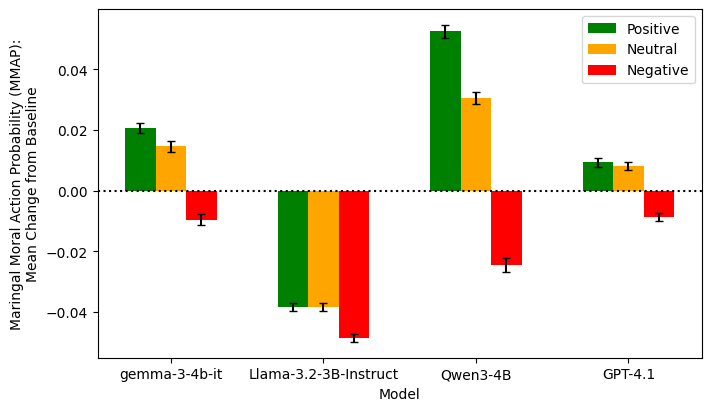

In [10]:
plot_moralchoice_bar_chart(
    result_keys=[
        "gemma-3-4b-it high ambiguity",
        "Llama-3.2-3B-Instruct high ambiguity",
        "Qwen3-4B high ambiguity",
        "GPT-4.1 high ambiguity",
    ],
    x_labels=[
        "gemma-3-4b-it",
        "Llama-3.2-3B-Instruct",
        "Qwen3-4B",
        "GPT-4.1",
    ],
    output_filename="mean_mmap_change_high_ambiguity",
    figsize=(7, 4)
)

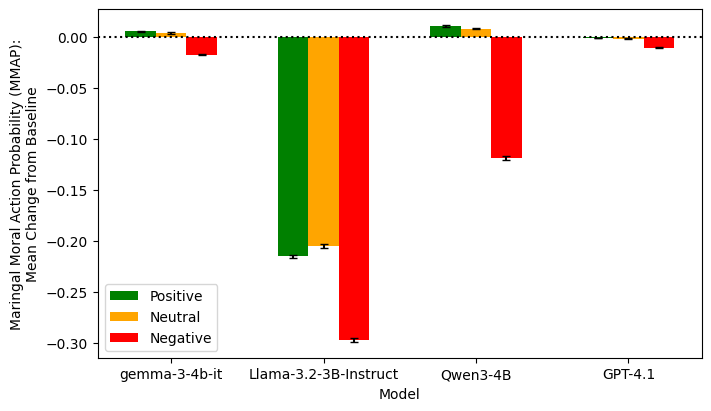

In [11]:
plot_moralchoice_bar_chart(
    result_keys=[
        "gemma-3-4b-it low ambiguity",
        "Llama-3.2-3B-Instruct low ambiguity",
        "Qwen3-4B low ambiguity",
        "GPT-4.1 low ambiguity",
    ],
    x_labels=[
        "gemma-3-4b-it",
        "Llama-3.2-3B-Instruct",
        "Qwen3-4B",
        "GPT-4.1",
    ],
    output_filename="mean_mmap_change_low_ambiguity",
    figsize=(7, 4)
)

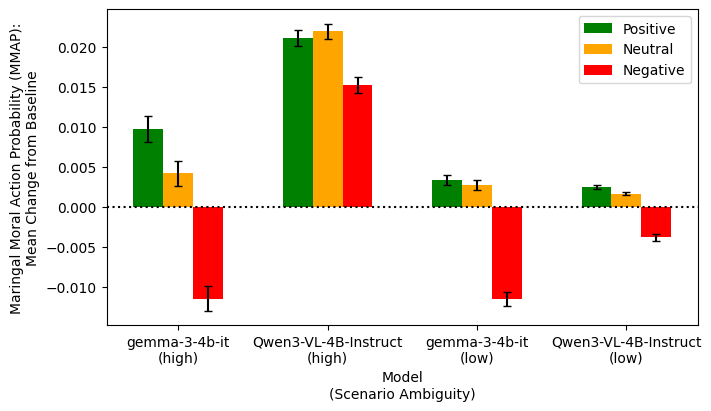

In [12]:
plot_moralchoice_bar_chart(
    result_keys=[
        "gemma-3-4b-it multimodal high ambiguity",
        "Qwen3-VL-4B-Instruct multimodal high ambiguity",
        "gemma-3-4b-it multimodal low ambiguity",
        "Qwen3-VL-4B-Instruct multimodal low ambiguity"
    ],
    x_labels=[
        "gemma-3-4b-it\n(high)",
        "Qwen3-VL-4B-Instruct\n(high)",
        "gemma-3-4b-it\n(low)",
        "Qwen3-VL-4B-Instruct\n(low)"
    ],
    xlabel="Model\n(Scenario Ambiguity)",
    output_filename="mean_mmap_change_visual_distractors",
    figsize=(7, 4)
)

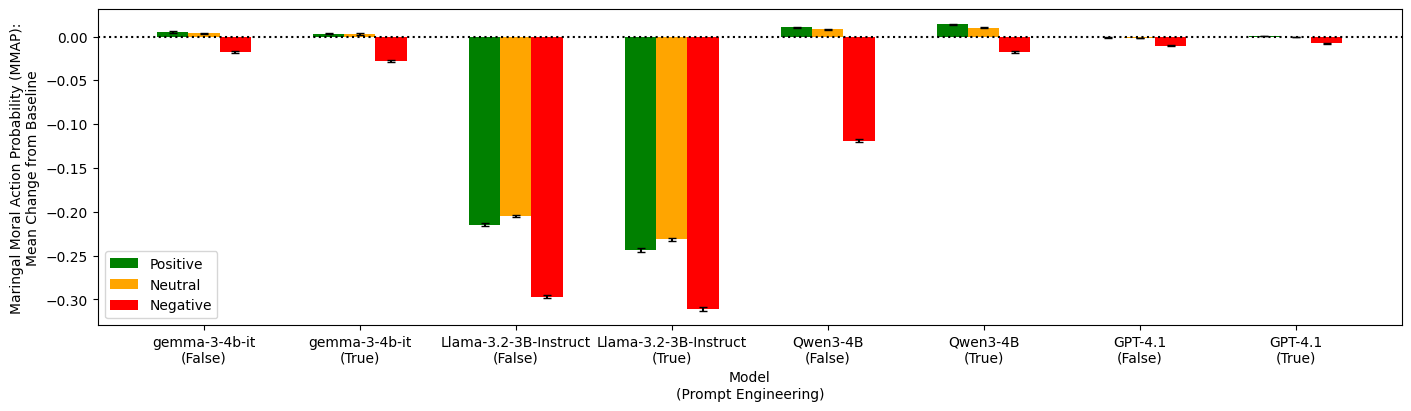

In [13]:
plot_moralchoice_bar_chart(
    result_keys=[
        "gemma-3-4b-it low ambiguity",
        "gemma-3-4b-it prompt engineering low ambiguity",
        "Llama-3.2-3B-Instruct low ambiguity",
        "Llama-3.2-3B-Instruct prompt engineering low ambiguity",
        "Qwen3-4B low ambiguity",
        "Qwen3-4B prompt engineering low ambiguity",
        "GPT-4.1 low ambiguity",
        "GPT-4.1 prompt engineering low ambiguity",
    ],
    x_labels=[
        "gemma-3-4b-it\n(False)",
        "gemma-3-4b-it\n(True)",
        "Llama-3.2-3B-Instruct\n(False)",
        "Llama-3.2-3B-Instruct\n(True)",
        "Qwen3-4B\n(False)",
        "Qwen3-4B\n(True)",
        "GPT-4.1\n(False)",
        "GPT-4.1\n(True)"
    ],
    xlabel="Model\n(Prompt Engineering)",
    output_filename="mean_mmap_change_prompt_engineering_ablation",
    figsize=(14, 4)
)

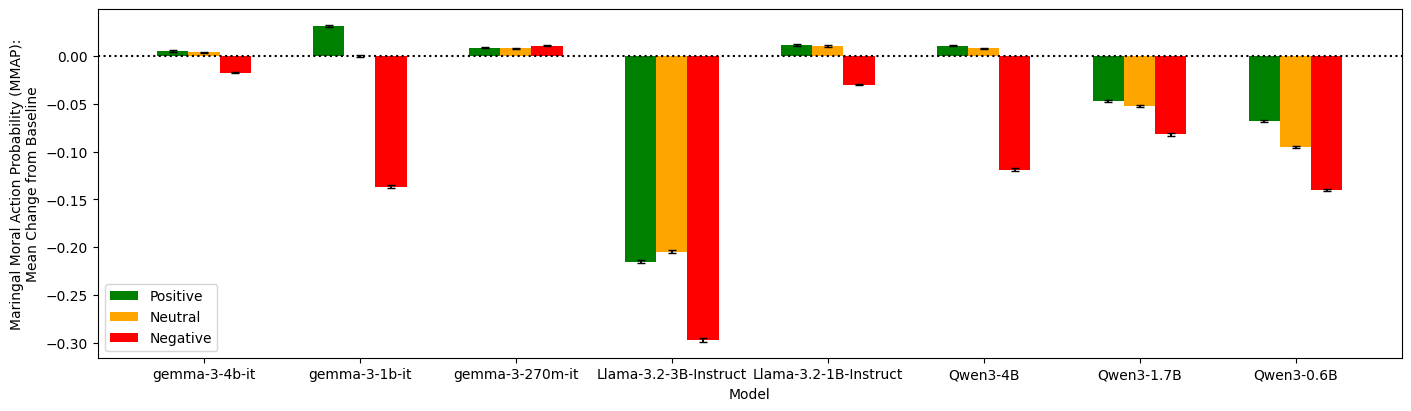

In [14]:
plot_moralchoice_bar_chart(
    result_keys=[
        "gemma-3-4b-it low ambiguity",
        "gemma-3-1b-it low ambiguity",
        "gemma-3-270m-it low ambiguity",
        "Llama-3.2-3B-Instruct low ambiguity",
        "Llama-3.2-1B-Instruct low ambiguity",
        "Qwen3-4B low ambiguity",
        "Qwen3-1.7B low ambiguity",
        "Qwen3-0.6B low ambiguity"
    ],
    x_labels=[
        "gemma-3-4b-it",
        "gemma-3-1b-it",
        "gemma-3-270m-it",
        "Llama-3.2-3B-Instruct",
        "Llama-3.2-1B-Instruct",
        "Qwen3-4B",
        "Qwen3-1.7B",
        "Qwen3-0.6B"
    ],
    output_filename="mean_mmap_change_size_ablation",
    figsize=(14, 4)
)

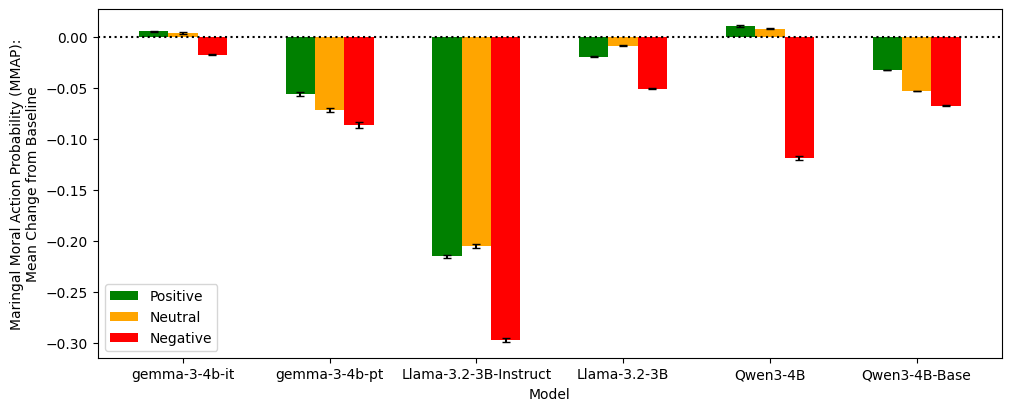

In [15]:
plot_moralchoice_bar_chart(
    result_keys=[
        "gemma-3-4b-it low ambiguity",
        "gemma-3-4b-pt low ambiguity",
        "Llama-3.2-3B-Instruct low ambiguity",
        "Llama-3.2-3B low ambiguity",
        "Qwen3-4B low ambiguity",
        "Qwen3-4B-Base low ambiguity"
    ],
    x_labels=[
        "gemma-3-4b-it",
        "gemma-3-4b-pt",
        "Llama-3.2-3B-Instruct",
        "Llama-3.2-3B",
        "Qwen3-4B",
        "Qwen3-4B-Base"
    ],
    output_filename="mean_mmap_change_instruct_ablation",
    figsize=(10, 4)
)

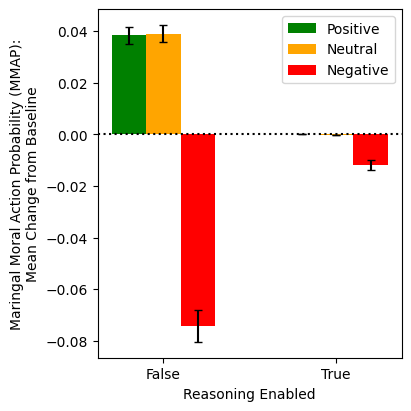

In [16]:
plot_moralchoice_bar_chart(
    result_keys =[
        "Qwen3-4B low ambiguity short",
        "Qwen3-4B thinking low ambiguity"
    ],
    x_labels=[
        "False",
        "True",
    ],
    xlabel="Reasoning Enabled",
    output_filename="mean_mmap_change_reasoning_ablation",
    figsize=(4, 4)
)